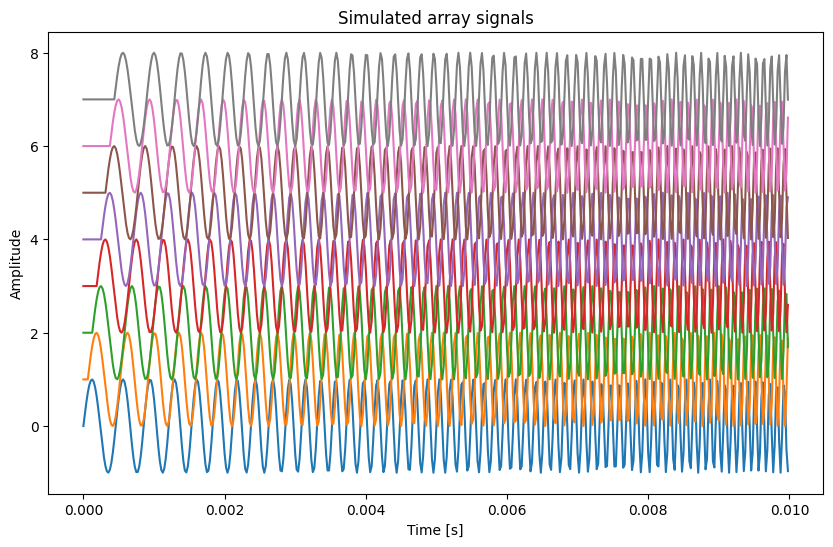

In [1]:
import sys
import os
sys.path.append(os.path.abspath("../scripts"))

from simulate_array import generate_chirp, create_array_signals


import matplotlib.pyplot as plt
import numpy as np

fs = 48000
duration = 0.01
f_start = 2000
f_end = 6000
array_length = 8
doa_deg = 30

t, chirp = generate_chirp(fs, duration, f_start, f_end)
signals = create_array_signals(chirp, fs, array_length, doa_deg)

plt.figure(figsize=(10, 6))
for i in range(array_length):
    plt.plot(t, signals[i] + i, label=f"Sensor {i}")
plt.title("Simulated array signals")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.show()

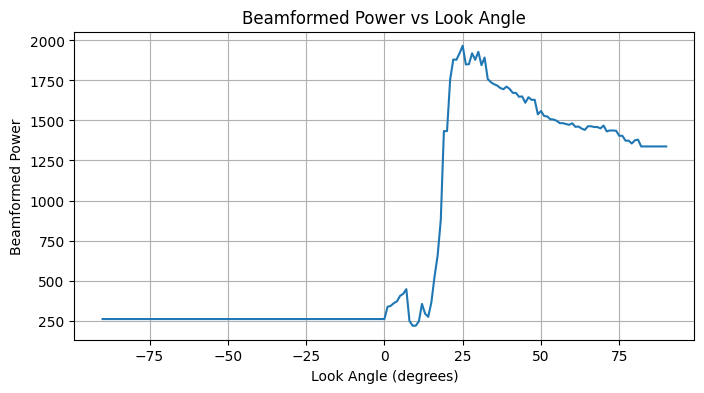

In [2]:
from simulate_array import delay_and_sum

# Compute beamforming output
f_avg = 0.5 * (f_start + f_end)
wavelength = 1500 / f_avg
d = wavelength / 2
angles = np.linspace(-90, 90, 181)

beam = delay_and_sum(signals, fs, angles, d)

# Plot beam pattern
plt.figure(figsize=(8, 4))
plt.plot(angles, beam)
plt.title("Beamformed Power vs Look Angle")
plt.xlabel("Look Angle (degrees)")
plt.ylabel("Beamformed Power")
plt.grid(True)
plt.show()
